In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Scikit-Learn tools for NLP & ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('customer_churn_nlp.csv')

print(f"Dataset shape : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"First 5 Customer Profiles: ")
df.head()

Dataset shape : 500 rows, 7 columns
First 5 Customer Profiles: 


,CustomerID,Tenure,MonthlyCharges,SupportTickets,Contract,CustomerFeedback,Churn
0,CUST-1000,40,35.09,0,One year,Customer support was very helpful and polite.,0
1,CUST-1001,22,50.26,0,One year,Smooth connection and fair monthly prices.,0
2,CUST-1002,13,64.71,1,Month-to-month,Excellent coverage and fast streaming experience.,0
3,CUST-1003,23,58.64,0,One year,"Great service, very happy with internet speed!",0
4,CUST-1004,53,27.57,2,One year,Easy billing process and fast resolution.,0


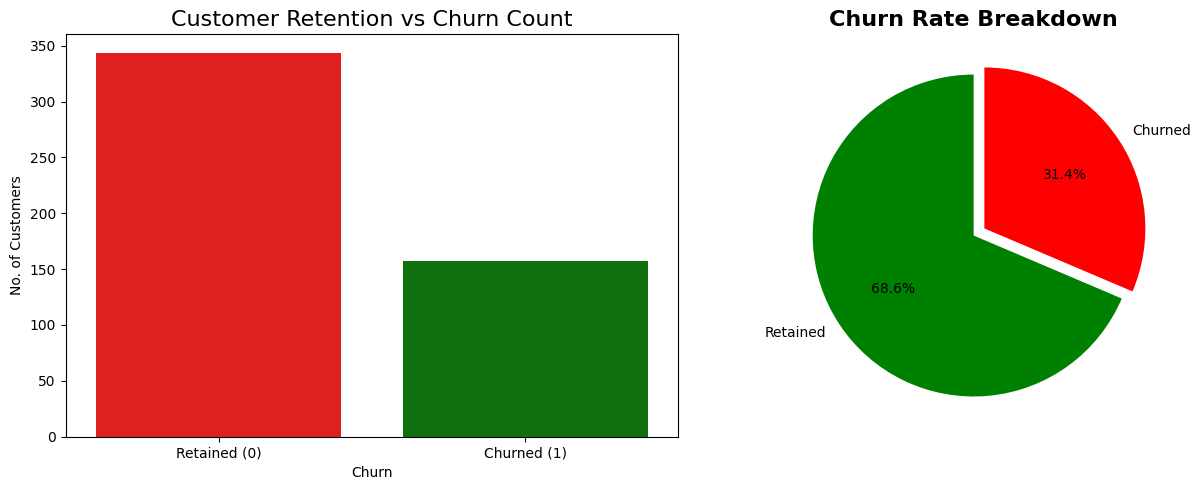

In [3]:
churn_counts=df['Churn'].value_counts()

fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.countplot(data=df,x='Churn',palette=['red','green'],ax=axes[0])
axes[0].set_title('Customer Retention vs Churn Count',fontsize=16)
axes[0].set_xticklabels(['Retained (0)','Churned (1)'])
axes[0].set_ylabel('No. of Customers')

axes[1].pie(churn_counts,labels=['Retained','Churned'],autopct='%1.1f%%',colors=['green','red'],startangle=90,explode=(0,0.08))
axes[1].set_title('Churn Rate Breakdown',fontsize=16,fontweight='bold')

plt.tight_layout()
plt.show()

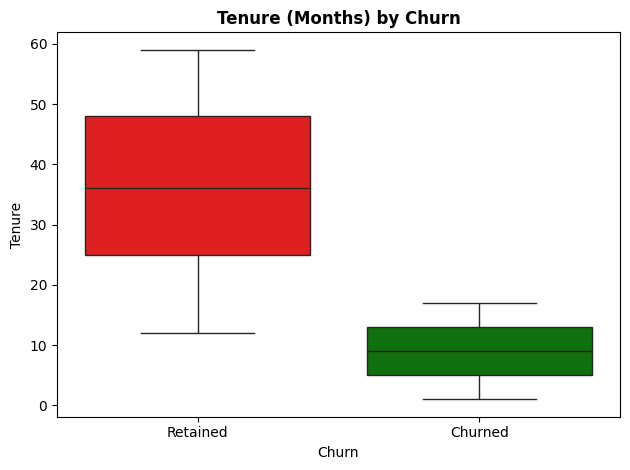

In [4]:
#Tenure vs Churn
sns.boxplot(data=df,x='Churn',y='Tenure',palette=['red','green'])
plt.title('Tenure (Months) by Churn',fontweight='bold')
plt.xticks([0,1],['Retained','Churned'])
plt.tight_layout()
plt.show()

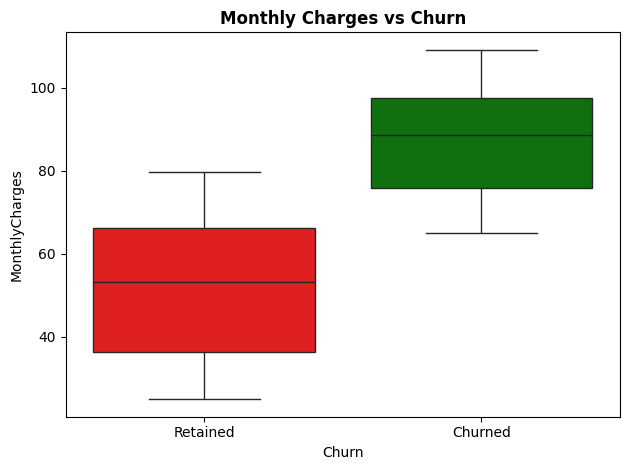

In [5]:
#Monthly Charges vs Churn
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',palette=['red','green'])
plt.title('Monthly Charges vs Churn',fontweight='bold')
plt.xticks([0,1],['Retained','Churned'])
plt.tight_layout()
plt.show()

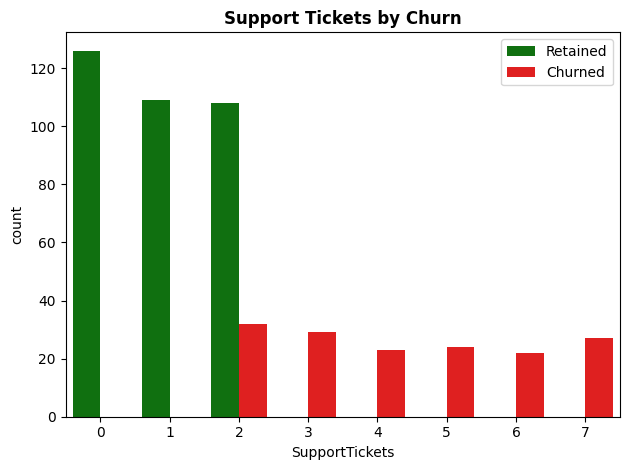

In [6]:
#Support Tickets vs Churn
sns.countplot(data=df,x='SupportTickets',hue='Churn',palette=['green','red'])
plt.title('Support Tickets by Churn',fontweight='bold')
plt.legend(['Retained','Churned'])
plt.tight_layout()
plt.show()

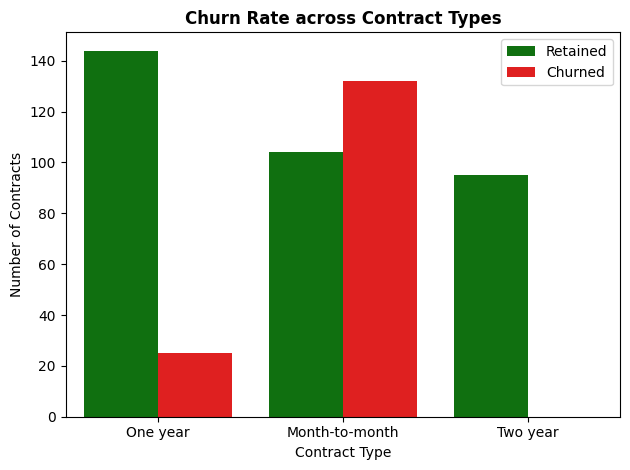

In [7]:
#Contract Type vs Churn
sns.countplot(data=df,x='Contract',hue='Churn',palette=['green','red'])
plt.title('Churn Rate across Contract Types',fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Contracts')
plt.legend(['Retained','Churned'])
plt.tight_layout()
plt.show()

In [8]:
#NLP Behaviour Analysis
print("--- Sample Feedback from Retained Customers ---")
for text in df[df['Churn']==0]['CustomerFeedback'].head(3):
    print(f"[Retained]: {text}")

print("\n--- Sample Feedback from Churned Customers ---")
for text in df[df['Churn']==1]['CustomerFeedback'].head(3):
    print(f"[Churned]: {text}")

--- Sample Feedback from Retained Customers ---
[Retained]: Customer support was very helpful and polite.
[Retained]: Smooth connection and fair monthly prices.
[Retained]: Excellent coverage and fast streaming experience.

--- Sample Feedback from Churned Customers ---
[Churned]: Bad experience, moving to another provider soon.
[Churned]: Cancel my subscription, worst customer care ever.
[Churned]: Monthly charges are way too expensive for bad service.


In [9]:
# 1. Encode Categorical Variable ('Contract)
df_contract_encoded=pd.get_dummies(df[['Contract']],drop_first=True,dtype=int)

# 2. Extract TF-IDF Features from Customer Feedback (15 top features for simplicity)
tfidf_vectorizer=TfidfVectorizer(max_features=15,stop_words='english',ngram_range=(1,2))
text_features=tfidf_vectorizer.fit_transform(df['CustomerFeedback']).toarray()

#Convert text features to DataFrame with clear column names
text_feature_names=[f"text_{word}" for word in tfidf_vectorizer.get_feature_names_out()]
df_text_encoded=pd.DataFrame(text_features,columns=text_feature_names)
print(df_text_encoded)
# 3. Select Numerical Features
df_numeric=df[['Tenure','MonthlyCharges','SupportTickets']]

# 4. Combine (Fuse) Numerical, Categorical and NLP text features
x=pd.concat([df_numeric,df_contract_encoded,df_text_encoded],axis=1)
y=df['Churn']

print(f"Combined Feature Matrix X Shape: {x.shape[0]} samples, {x.shape[1]} features")
print("Feature Column List: ")
print(list(x.columns))

     text_care  text_connection  text_customer  text_customer care  \
0          0.0         0.000000            1.0                 0.0   
1          0.0         0.710409            0.0                 0.0   
2          0.0         0.000000            0.0                 0.0   
3          0.0         0.000000            0.0                 0.0   
4          0.0         0.000000            0.0                 0.0   
..         ...              ...            ...                 ...   
495        0.0         0.000000            0.0                 0.0   
496        0.0         0.000000            0.0                 0.0   
497        0.0         0.000000            0.0                 0.0   
498        0.0         1.000000            0.0                 0.0   
499        0.0         0.000000            0.0                 0.0   

     text_excellent  text_excellent coverage  text_experience  text_fast  \
0          0.000000                 0.000000         0.000000   0.000000   
1      

In [10]:
#Split dataset 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

print(f"Target set size: {x_train.shape[0]} samples")
print(f"Testing set size: {x_test.shape[0]} samples")

#Model 1: Logistic Regression
model_lr=LogisticRegression(max_iter=1000,random_state=42)
model_lr.fit(x_train,y_train)
y_pred_lr=model_lr.predict(x_test)
acc_lr=accuracy_score(y_test,y_pred_lr)
print(f"Logistic Regression Accuracy Score: {acc_lr:.2%}")

#Model 2: Random Forest 
model_rf=RandomForestClassifier(n_estimators=100,random_state=42)
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)
acc_rf=accuracy_score(y_test,y_pred_rf)
print(f"Random Forest Accuracy Score: {acc_rf:.2%}")

Target set size: 400 samples
Testing set size: 100 samples
Logistic Regression Accuracy Score: 100.00%
Random Forest Accuracy Score: 100.00%


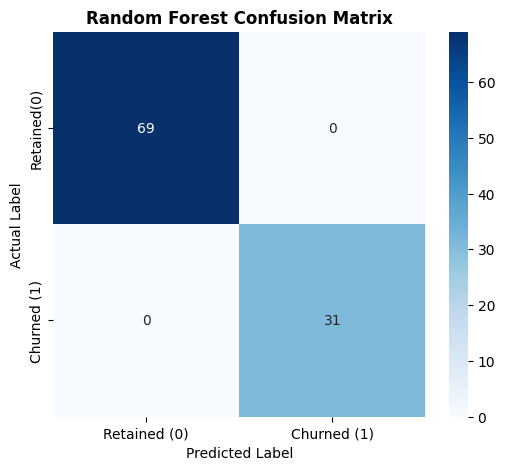

--- Detailed Classification Report (Random Forest) ---
              precision    recall  f1-score   support

Retained (0)       1.00      1.00      1.00        69
 Churned (1)       1.00      1.00      1.00        31

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [13]:
#Model Evaluation using confusion matrix
cm=confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Retained (0)','Churned (1)'],yticklabels=['Retained(0)','Churned (1)'])
plt.title('Random Forest Confusion Matrix',fontsize=12,fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

#Classification Report 
print("--- Detailed Classification Report (Random Forest) ---")
print(classification_report(y_test,y_pred_rf,target_names=['Retained (0)','Churned (1)']))

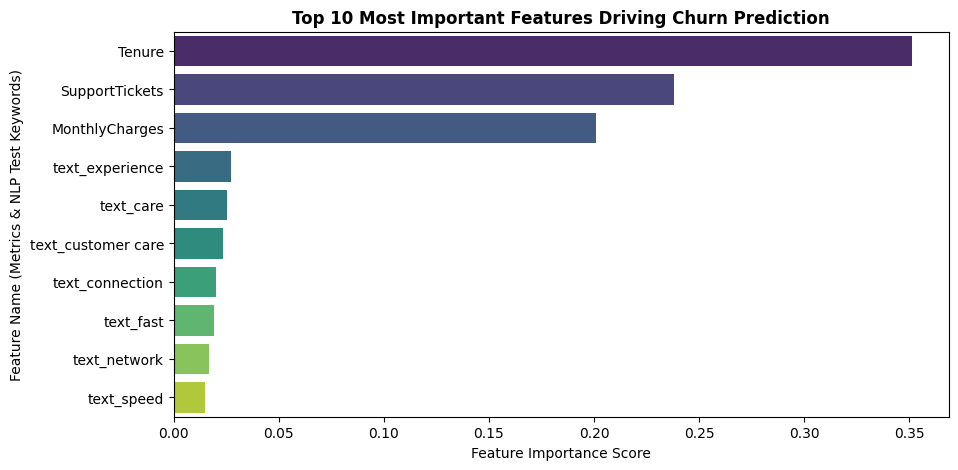

In [14]:
#Feature importace
feature_importances=pd.Series(model_rf.feature_importances_,index=x.columns)
top_features=feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_features.values,y=top_features.index,palette='viridis')
plt.title("Top 10 Most Important Features Driving Churn Prediction",fontsize=12,fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name (Metrics & NLP Test Keywords)')
plt.show()

In [20]:
#Live Interaction
def predict_customer_churn(tenure,monthly_charges,support_tickets,contract_type,feedback_text):
    input_dict={
        'Tenure':[tenure],
        'MonthlyCharges':[monthly_charges],
        'SupportTickets':[support_tickets],
        'Contract_One year':[1 if contract_type == 'One year' else 0],
        'Contract_Two year':[1 if contract_type == 'Two year' else 0]
    }

    # 3. Transform text using fitted TF-IDF Vecotrizer
    text_vectorized=tfidf_vectorizer.transform([feedback_text]).toarray()
    for i,col_name in enumerate(text_feature_names):
        input_dict[col_name]=[text_vectorized[0][i]]

    # 3. Create single row DataFrame matching training features
    df_input=pd.DataFrame(input_dict)[x.columns]

    # 4. Predict Churn Probability using Random Forest Model
    churn_prob=model_rf.predict_proba(df_input)[0][1]
    is_churn=churn_prob>=0.5

    # 5. Output Results & Recommendation
    print("=" * 60)
    print("        Customer Churn Risk Assessment Report     ")
    print('=' * 60)
    print(f"Customer Input Profile:")
    print(f"Tenure: {tenure} months ")
    print(f"Monthly Bill: ${monthly_charges:.2f}")
    print(f"Support Tickets: {support_tickets}")
    print(f"Contract Type: {contract_type}")
    print(f"Feedback Review: {feedback_text}")
    print("-"*60)
    print(f"Churn Probability: {churn_prob*100:.1f}%")

    if is_churn:
        print("Risk Status : High Risk of Churning (Danger)")
        print("Suggested Action : Trigger Retention Offer!")
        print("                   ->Offer 15% discount on 1-year Contract.")
        print("                   ->Schedule priority customer support callback.")
    else:
        print("Risk Status: Retained (Low Risk)")
        print("Suggested Action : No intervention needed. Send thank you offer.")
    print("="*60)
    print("\n")

# Test Case 1: High Customer (Short tenure,expensive,bad feedback)
predict_customer_churn(
    tenure=2,
    monthly_charges=95.50,
    support_tickets=5,
    contract_type='Month-to-month',
    feedback_text='Terrible internet speed, disconnects constantly! Overpriced charges'
)

# Test Case 2 : Low Risk Customer
predict_customer_churn(
    tenure=36,
    monthly_charges=45.00,
    support_tickets=0,
    contract_type='Two year',
    feedback_text='Love the service, smooth connection and very helpful customer care!'
)

        Customer Churn Risk Assessment Report     
Customer Input Profile:
Tenure: 2 months 
Monthly Bill: $95.50
Support Tickets: 5
Contract Type: Month-to-month
Feedback Review: Terrible internet speed, disconnects constantly! Overpriced charges
------------------------------------------------------------
Churn Probability: 100.0%
Risk Status : High Risk of Churning (Danger)
Suggested Action : Trigger Retention Offer!
                   ->Offer 15% discount on 1-year Contract.
                   ->Schedule priority customer support callback.


        Customer Churn Risk Assessment Report     
Customer Input Profile:
Tenure: 36 months 
Monthly Bill: $45.00
Support Tickets: 0
Contract Type: Two year
Feedback Review: Love the service, smooth connection and very helpful customer care!
------------------------------------------------------------
Churn Probability: 0.0%
Risk Status: Retained (Low Risk)
Suggested Action : No intervention needed. Send thank you offer.


